In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
np.random.seed(42)
n = 300


size             = np.random.randint(500,4000, n)
bedrooms         = np.random.randint(1,6,n)
age              = np.random.randint(0,50,n)
location_score   = np.random.randint(1,11,n)
garage           = np.random.randint(0,2,n)

noise = np.random.normal(0,15000, n)

price = (150 * size) + (8000 * bedrooms) - (500 * age) + (10000 * location_score) + (20000 * garage) + noise

df = pd.DataFrame({
    'size'           : size,
    'bedrooms'       : bedrooms,
    'age'            : age,
    'location_score' : location_score,
    'garage'         : garage,
    'price'          : price
})


print("Dataset Shape :", df.shape)
df.head(10)



Dataset Shape : (300, 6)


,size,bedrooms,age,location_score,garage,price
0,3674,4,46,9,1,665483.215750
1,1360,1,15,10,1,314616.523670
2,1794,1,4,9,1,395056.058208
3,1630,2,34,9,0,348652.121906
4,1595,1,11,6,0,288720.892161
5,3592,3,24,8,0,631471.503006
6,2138,4,20,1,0,371967.995509
7,2669,1,35,10,1,521185.543048
8,966,1,22,4,0,194465.461576
9,1738,2,15,1,0,299719.779612


In [9]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(300, 6)
size                int32
bedrooms            int32
age                 int32
location_score      int32
garage              int32
price             float64
dtype: object
size              0
bedrooms          0
age               0
location_score    0
garage            0
price             0
dtype: int64


In [12]:
df.describe()

,size,bedrooms,age,location_score,garage,price
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2341.816667,2.950000,23.806667,5.650000,0.483333,430641.734230
std,995.267929,1.447232,14.582345,2.834481,0.500557,153669.232865
min,501.000000,1.000000,0.000000,1.000000,0.000000,107578.441524
25%,1535.500000,2.000000,11.000000,3.000000,0.000000,306842.551620
50%,2281.000000,3.000000,24.000000,6.000000,0.000000,425120.045615
75%,3231.750000,4.000000,36.000000,8.000000,1.000000,561949.137397
max,3999.000000,5.000000,49.000000,10.000000,1.000000,725422.561102


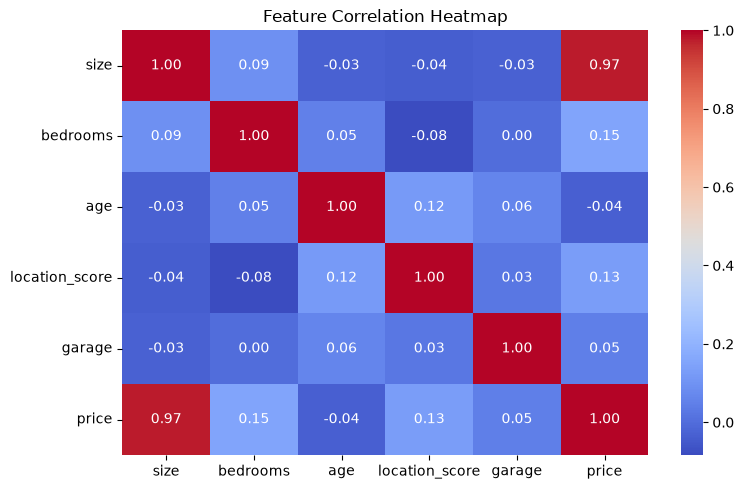

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot = True, fmt='0.2f', cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

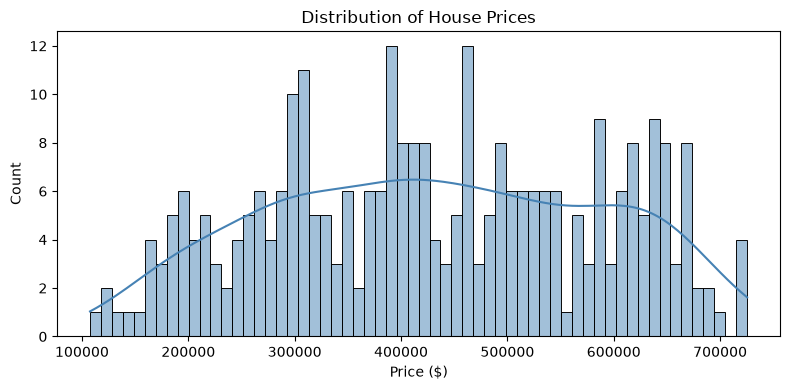

In [29]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=60, kde=True, color='steelblue')
plt.title("Distribution of House Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

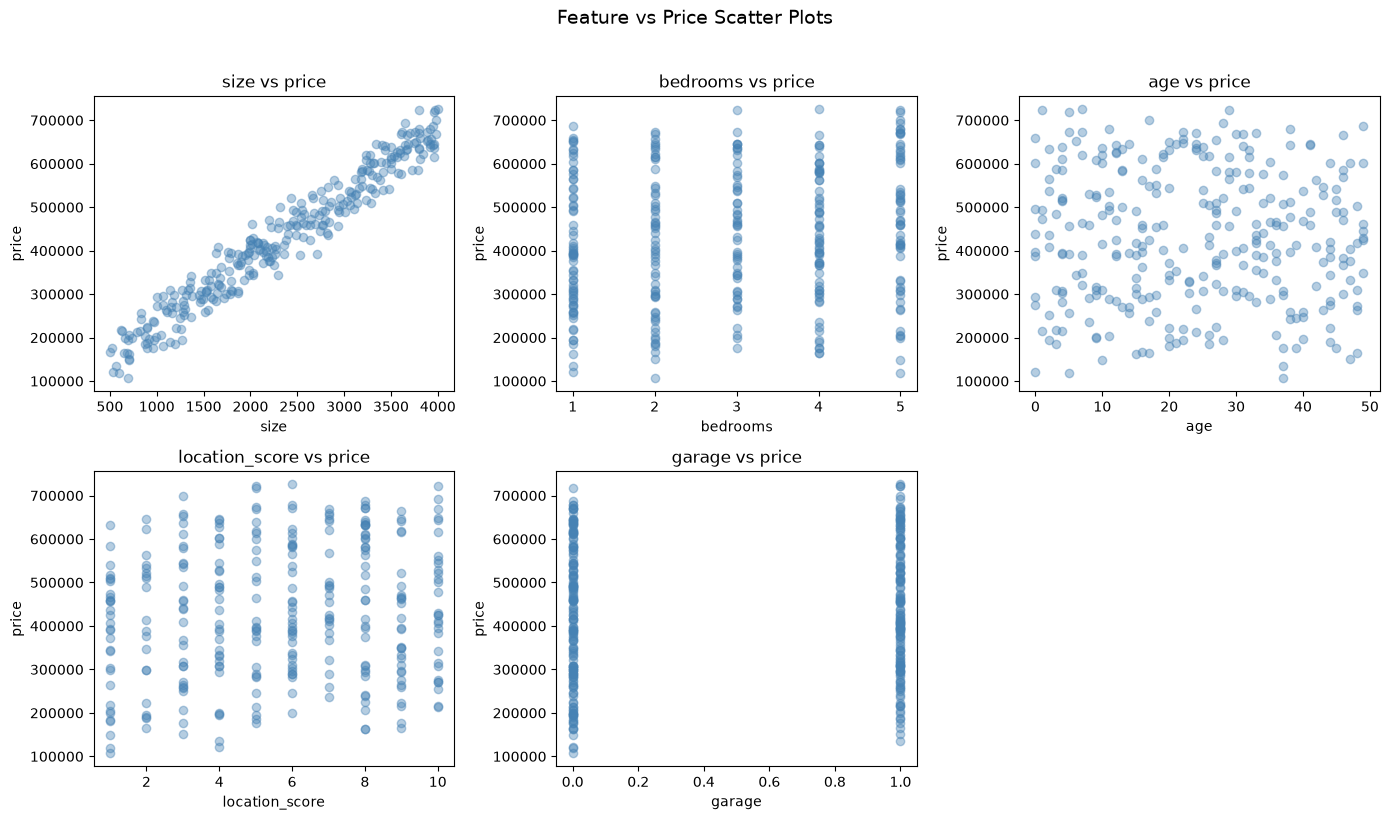

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

features = ['size', 'bedrooms', 'age', 'location_score', 'garage']

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['price'], alpha=0.4, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('price')
    axes[i].set_title(f"{feature} vs price")

axes[5].axis('off')

plt.suptitle("Feature vs Price Scatter Plots", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
    